In [1]:
setwd('/home/eouser/Baringo_Prospect/')
library(prospect)
library(signal)
library(dplyr)
source("Scripts/prospect_fuctions.r")
assignInNamespace("invert_prospect", invert_prospect_fixed, ns = "prospect")



Attaching package: ‘signal’


The following objects are masked from ‘package:stats’:

    filter, poly



Attaching package: ‘dplyr’


The following object is masked from ‘package:signal’:

    filter


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
#Loading data
reflect <- read.table(
  "Data/Reflectance_merged.txt",
  header = TRUE
)

transmit <- read.table(
  "Data/merged_scaled_transmittance_W.txt",
  header = TRUE
)
results <- read.csv(
  "Data/results_filtered_LMA_N_TW.csv"
)
results <- distinct(results, Sample, .keep_all = T)
results$Species <- trimws(results$Species)

In [3]:
reflect_l <- reflect[reflect$wavelength >= 750 & reflect$wavelength <= 900, ]
transmit_l <- transmit[transmit$wavelength >= 750 & transmit$wavelength <= 900, ]

lambda <- reflect_l$wavelength

#refl_samples <- reflect_l[, -1] %>% select(-'S387')
#trans_samples <- transmit_l[, -1] %>% select(-'S387')
refl_samples <- reflect_l[, -1] 
trans_samples <- transmit_l[, -1]
# ==========================================================
# Apply Savitzky-Golay smoothing
# ==========================================================

sg_order <- 3
sg_window <- 11

refl_smoothed <- as.data.frame(
  apply(refl_samples, 2, smooth_spectrum, p = sg_order, n = sg_window)
)

trans_smoothed <- as.data.frame(
  apply(trans_samples, 2, smooth_spectrum, p = sg_order, n = sg_window)
)

cat("Smoothing applied: SG filter, order =", sg_order, ", window =", sg_window, "\n")


Smoothing applied: SG filter, order = 3 , window = 11 


In [4]:
sample_names <- unique(results$Sample)

retrieval_results <- data.frame(
  Sample        = character(length(sample_names)),
  retrieved_N   = numeric(length(sample_names)),
  Retrieved_LMA = numeric(length(sample_names)),
  Retrieved_EWT = numeric(length(sample_names)),
  stringsAsFactors = FALSE
)

N_values<- data.frame(
    Sample= character(length(sample_names)),
    Retrieved_N_LMA = as.numeric(length(sample_names)),
    Estimated_N = as.numeric(length(sample_names)),
    stringsAsFactors = FALSE
)

In [5]:
# ==========================================================
# Parameters to estimate
# ==========================================================

parms_to_estimate <- c("lma", 'chl')

# ==========================================================
# Loop through samples
# ==========================================================

for (i in seq_along(sample_names)) {
  
  sample_name <- sample_names[i]
  match_idx <- which(results$Sample == sample_name)
  
  if (length(match_idx) == 0) {
    warning(paste("No match found for sample:", sample_name))
    next
  }
  
  # Get estimated N from previous optimization
  n_struct_value <- results$Estimated_N[match_idx]
  
  # Fit spectral data
  subset_lop <- fit_spectral_data(
    lambda = lambda,
    refl = refl_smoothed[, sample_name],
    tran = trans_smoothed[, sample_name]
  )
  
  options <- set_options_prospect(fun = 'invert_prospect')
  options$merit_function <- merit_prospect_absorptance
  options$spec_prospect <- subset_lop$spec_prospect
  # Fix N to previously estimated value
  options$fix_values <- list(n_struct = n_struct_value)
  options$lower <- list(lma = 0.001, chl = 40)
  options$upper <- list(lma = 0.060, chl = 40)
  # Run inversion
  res <- invert_prospect(
    refl = subset_lop$refl,
    tran = subset_lop$tran,
    prospect_version = 'D',
    parms_to_estimate = parms_to_estimate,
    options = options
  )
  
  # Store results
    retrieval_results$Sample[match_idx]        <- sample_name
    retrieval_results$Retrieved_N[match_idx]   <- n_struct_value
    retrieval_results$Retrieved_LMA[match_idx] <- res$lma * 1000
    N_values$Retrieved_N_LMA[match_idx] <- res$n_struct
    N_values$Estimated_N[match_idx] <- n_struct_value
    N_values$Sample[match_idx]<- sample_name



  
  print(
    paste(
      "Sample:", sample_name,
      "| N:", round(n_struct_value, 3),
      "| LMA:", round(res$lma * 1000, 4),
      "| EWT:", round(res$ewt, 5)
    )
  )
}

[1] "Sample: S100 | N: 1.535 | LMA: 6.5457 | EWT: 0.01"
[1] "Sample: S101 | N: 2.389 | LMA: 4.4933 | EWT: 0.01"
[1] "Sample: S102 | N: 1.709 | LMA: 1.9781 | EWT: 0.01"
[1] "Sample: S104 | N: 1.404 | LMA: 11.8283 | EWT: 0.01"
[1] "Sample: S108 | N: 1.742 | LMA: 9.3006 | EWT: 0.01"
[1] "Sample: S109 | N: 1.619 | LMA: 10.4835 | EWT: 0.01"
[1] "Sample: S113 | N: 2.286 | LMA: 9.7863 | EWT: 0.01"
[1] "Sample: S118 | N: 1.528 | LMA: 7.8274 | EWT: 0.01"
[1] "Sample: S12 | N: 2.012 | LMA: 8.1982 | EWT: 0.01"
[1] "Sample: S120 | N: 1.868 | LMA: 3.5551 | EWT: 0.01"
[1] "Sample: S122 | N: 1.543 | LMA: 0.7128 | EWT: 0.01"
[1] "Sample: S13 | N: 1.77 | LMA: 13.3905 | EWT: 0.01"
[1] "Sample: S130 | N: 1.935 | LMA: 28.631 | EWT: 0.01"
[1] "Sample: S131 | N: 1.82 | LMA: 15.9052 | EWT: 0.01"
[1] "Sample: S132 | N: 2.562 | LMA: 14.1027 | EWT: 0.01"
[1] "Sample: S139 | N: 2.283 | LMA: 13.5024 | EWT: 0.01"
[1] "Sample: S14 | N: 1.282 | LMA: 4.4502 | EWT: 0.01"
[1] "Sample: S141 | N: 2.343 | LMA: 14.7867 | E

In [6]:
retrieval_results1 <- results %>%
  left_join(
    retrieval_results %>%
      select(Sample, Retrieved_LMA) %>%
      distinct(Sample, .keep_all = TRUE),
    by = "Sample"
  )
retrieval_results1$Estimated_LMA <- retrieval_results1$Estimated_LMA*1000

head(retrieval_results1)
#write.csv(N_values, 'N_values.csv', row.names = F)

,Sample,Species,R_Max_Reflectance,T_At_Max_Reflectance,WL_Max_Reflectance,R_At_Max_Transmittance,T_Max_Transmittance,WL_Max_Transmittance,R_Min_Absorptance,T_Min_Absorptance,⋯,EWT,Cab,Estimated_N,Estimated_LMA,Objective,RMSE_Reflectance,RMSE_Transmittance,RMSE_Absorptance,Mean_RMSE,Retrieved_LMA
,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,S100,Prosopis,0.4193701,0.4381989,888,0.4178830,0.4395613,897,0.4187824,0.4393480,⋯,15.6088,NA,1.535061,16.411083,1.992861e-06,0.04657439,0.03642953,0.011376312,0.04150196,6.545717
2,S101,Prosopis,0.5627156,0.3499319,776,0.5530249,0.3654848,900,0.5600318,0.3602657,⋯,9.8557,38.257,2.388892,8.836416,1.711188e-04,0.01536605,0.02617516,0.011351717,0.02077061,4.493309
3,S102,Prosopis,0.4651295,0.4245779,847,0.4617754,0.4320892,894,0.4625572,0.4315484,⋯,10.5549,NA,1.709181,11.864570,3.831713e-05,0.03254341,0.05908718,0.026803295,0.04581530,1.978099
4,S104,Prosopis,0.3755468,0.4307199,840,0.3717666,0.4391183,900,0.3717666,0.4391183,⋯,14.4449,NA,1.403978,23.388219,5.229251e-05,0.05381689,0.02849730,0.025838804,0.04115709,11.828332
5,S108,Prosopis,0.4393952,0.3897773,778,0.4361493,0.3986602,888,0.4367856,0.3981263,⋯,15.9150,24.246,1.741744,19.847513,5.847191e-05,0.05294308,0.03153691,0.021662296,0.04223999,9.300650
6,S109,Prosopis,0.4246654,0.4175575,893,0.4225351,0.4185517,900,0.4246654,0.4175575,⋯,16.0819,NA,1.619150,18.571609,3.337723e-06,0.03827285,0.03357317,0.007690883,0.03592301,10.483451


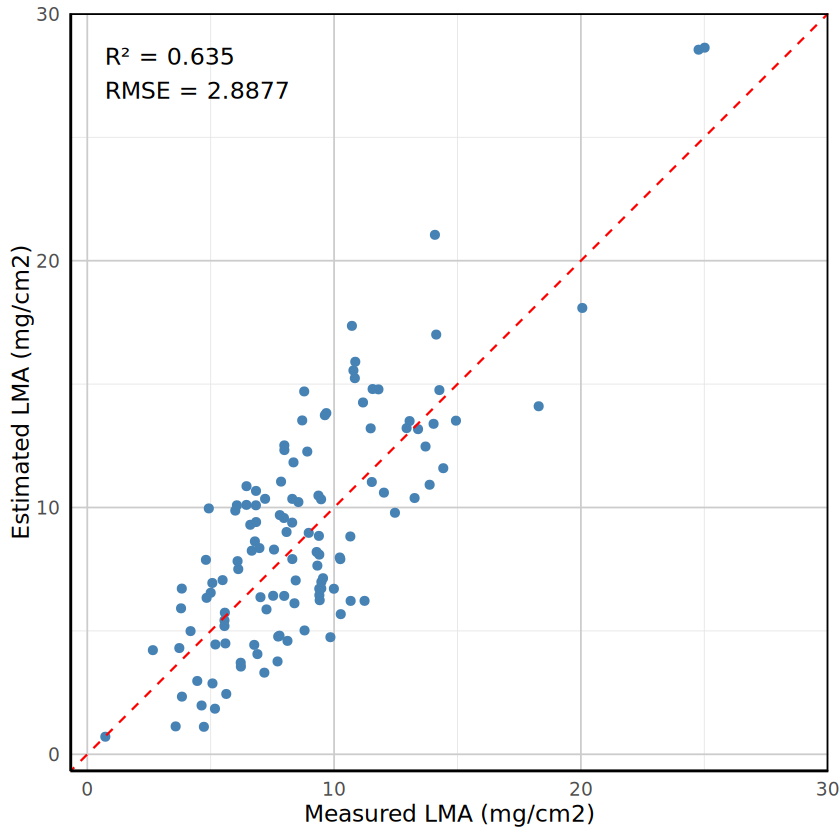

In [8]:
library(ggplot2)

# ---- Compute Accuracy Metrics ----
fit <- lm(LMA ~ Retrieved_LMA, data = retrieval_results1)
r_squared <- summary(fit)$r.squared
rmse <- sqrt(mean((retrieval_results1$LMA - retrieval_results1$Retrieved_LMA)^2))

metrics_text <- paste0(
  "R² = ", round(r_squared, 3), "\n",
  "RMSE = ", round(rmse, 4)
)

# ---- Common axis limits for comparability ----
axis_limits <- range(retrieval_results1$LMA, retrieval_results$Retrieved_LMA, na.rm = TRUE)


plot <- ggplot(data = retrieval_results1, aes(x = LMA, y = Retrieved_LMA)) +
  geom_point(color = "steelblue", size = 2) +
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
  annotate(
    "text",
    x = axis_limits[1],
    y = axis_limits[2],
    label = metrics_text,
    hjust = 0,
    vjust = 1,
    size = 5,
    color = "black"
  ) +
  coord_equal(xlim = axis_limits, ylim = axis_limits) +
  labs(
    #title = "PROSPECT Inversion: Measured vs Estimated LMA",
    x = "Measured LMA (mg/cm2)",
    y = "Estimated LMA (mg/cm2)"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid.major = element_line(color = "gray80", linewidth = 0.5),
    panel.grid.minor = element_line(color = "gray90", linewidth = 0.25),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    axis.line = element_line(color = "black"),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

ggsave("lmawithNnotfixed_plot.png", plot = plot, width = 6, height = 6, dpi = 300)

plot


In [ ]:
library(ggplot2)
library(dplyr)

# Common axis range across all panels
axis_limits <- range(retrieval_results1$LMA, retrieval_results1$Retrieved_LMA, na.rm = TRUE)

# Add padding (VERY important so text doesn't touch borders)
pad <- 0.05 * diff(axis_limits)

metrics_by_species <- retrieval_results1 |>
  dplyr::group_by(Species) |>
  dplyr::summarise(
    r_squared = {
      if (sum(!is.na(LMA) & !is.na(Retrieved_LMA)) >= 2) {
        summary(lm(LMA ~ Retrieved_LMA, data = cur_data()))$r.squared
      } else NA_real_
    },
    rmse = sqrt(mean((LMA - Retrieved_LMA)^2, na.rm = TRUE)),
    .groups = "drop"
  ) |>
  dplyr::mutate(
    metrics_text = paste0("R\u00B2 = ", round(r_squared, 3),
                          "\nRMSE = ", round(rmse, 4)),
    x = axis_limits[1] + pad,   # moved inward
    y = axis_limits[2] - pad    # moved inward
  )

p <- ggplot(retrieval_results1, aes(x = LMA, y = Retrieved_LMA)) +
  geom_point(color = "steelblue", size = 1.2, alpha = 0.85) +   # smaller points
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
  facet_wrap(~ Species, scales = "fixed") +
  geom_text(
    data = metrics_by_species,
    aes(x = x, y = y, label = metrics_text),
    hjust = 0, vjust = 1,
    size = 3.5,
    color = "black",
    inherit.aes = FALSE
  ) +
  coord_equal(
    xlim = axis_limits + c(-pad, pad),
    ylim = axis_limits + c(-pad, pad),
    expand = FALSE
  ) +
  labs(x = "Measured LMA (mg/cm2)", y = "Estimated LMA (mg/cm2)") +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.major = element_line(color = "gray80", linewidth = 0.5),
    panel.grid.minor = element_line(color = "gray90", linewidth = 0.25),
    strip.text = element_text(face = "bold"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.8),
    axis.line = element_line(color = "black")
  )

ggsave("lma_by_species_facet.png", plot = p, width = 9, height = 7, dpi = 300)
p

In [ ]:
#------Inversion for lwc using 1000-1300nm
reflect<- reflect[reflect$wavelength >= 900 & reflect$wavelength <= 1900 , ]
transmit <- transmit[transmit$wavelength >= 900 & transmit$wavelength <= 1900, ]

lambda <- reflect$wavelength

refl_samples <- reflect[, -1]
refl_samples <- refl_samples 

trans_samples <- transmit[, -1]
trans_samples <- trans_samples 

# ==========================================================
# Apply Savitzky-Golay smoothing to all spectra
# ==========================================================

# Smoothing parameters
sg_order <- 3    # polynomial order
sg_window <- 11  # window size (must be odd)

# Smooth reflectance
refl_smoothed <- as.data.frame(
  apply(refl_samples, 2, smooth_spectrum, p = sg_order, n = sg_window)
)

# Smooth transmittance
trans_smoothed <- as.data.frame(
  apply(trans_samples, 2, smooth_spectrum, p = sg_order, n = sg_window)
)

# Ensure values stay in valid range [0, 1]
#refl_smoothed <- pmax(pmin(refl_smoothed, 1), 0)
#trans_smoothed <- pmax(pmin(trans_smoothed, 1), 0)

cat("Smoothing applied: SG filter, order =", sg_order, ", window =", sg_window, "\n")
# ==========================================================
# Storage
# ==========================================================

In [ ]:

# ==========================================================
# Parameters to estimate
# ==========================================================

parms_to_estimate <- c("ewt","chl")

# ==========================================================
# Loop through samples
# ==========================================================

for (sample_name in sample_names) {
  
  match_idx     <- which(results$Sample == sample_name)
  match_idx_lma <- which(retrieval_results$Sample == sample_name)
  
  if (length(match_idx) == 0 || length(match_idx_lma) == 0) {
    warning(paste("No match found for sample:", sample_name))
    next
  }
  
  n_struct_value <- results$Estimated_N[match_idx]
  lma_ret        <- retrieval_results$Retrieved_LMA[match_idx_lma]
  
  subset_lop <- fit_spectral_data(
    lambda = lambda,
    refl   = refl_smoothed[, sample_name],
    tran   = trans_smoothed[, sample_name]
  )
  
  options <- set_options_prospect(fun = 'invert_prospect')
  options$merit_function <- merit_prospect_absorptance
  options$spec_prospect <- subset_lop$spec_prospect
  
  # Fix N and LMA to previously retrieved values; estimate EWT only
  options$fix_values  <- list(n_struct = n_struct_value, lma = lma_ret/1000)
    options$lower <- list(ewt = 0.001, chl =40)
    options$upper <- list(ewt = 0.10, chl = 40)
 
  
  res <- invert_prospect(
    refl              = subset_lop$refl,
    tran              = subset_lop$tran,
    prospect_version  = 'D',
    parms_to_estimate = parms_to_estimate,          
    options           = options
  )
  
  retrieval_results$Retrieved_EWT2[match_idx_lma] <- res$ewt * 1000
  
  print(
    paste(
      "Sample:", sample_name,
      "| N:", round(n_struct_value, 3),
      "| CHL:", round(res$chl, 4), "g/m²",
      "| EWT:", round(res$ewt*1000,4)
    )
  )
}

In [ ]:
retrieval_results2 <- results %>%
  left_join(
    retrieval_results %>%
      select(Sample, Retrieved_EWT2, Retrieved_LMA) %>%
      distinct(Sample, .keep_all = TRUE),
    by = "Sample"
  )
retrieval_results2 <- retrieval_results2[retrieval_results2$EWT >= 0,]
#retrieval_results2 <- retrieval_results2[retrieval_results2$EWT <= 40,]

In [ ]:

# ---- Compute Accuracy Metrics ----
fit <- lm(EWT ~Retrieved_EWT2, data = retrieval_results2)
r_squared <- summary(fit)$r.squared
rmse <- sqrt(mean((retrieval_results2$EWT - retrieval_results2$Retrieved_EWT2)^2))
metrics_text <- paste0(
  "R² = ", round(r_squared, 3), "\n",
  "RMSE = ", round(rmse, 4), "\n")
axis_limits <- range(retrieval_results2$EWT, retrieval_results2$Retrieved_EWT2, na.rm = TRUE)
plot <- ggplot(data = retrieval_results2, aes(x = EWT, y = (Retrieved_EWT2))) +
  geom_point(color = 'steelblue', size = 2) +
  geom_abline(slope = 1, intercept = 0, color = 'red', linetype = 'dashed') +
  annotate("text", 
           x = axis_limits[1], 
           y = axis_limits[2], 
           label = metrics_text, 
           hjust = 0, vjust = 1,
           size = 5, color = "black") +
    coord_equal(xlim = axis_limits, ylim = axis_limits) +
  labs(
    #title = "PROSPECT Inversion: Measured vs Estimated EWT",
    x = 'Measured EWT(mg/cm2)',
    y = 'Estimated EWT(mg/cm2)'
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid.major = element_line(color = "gray80", size = 0.5),
    panel.grid.minor = element_line(color = "gray90", size = 0.25),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    axis.line = element_line(color = "black"),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )
ggsave("ewt_900_1900_plot.png", plot = plot, width = 6, height = 6, dpi = 300)

plot

In [ ]:
library(ggplot2)
library(dplyr)

# Common axis range across all panels
axis_limits <- range(retrieval_results2$EWT, retrieval_results2$Retrieved_EWT2, na.rm = TRUE)

# Add padding (VERY important so text doesn't touch borders)
pad <- 0.05 * diff(axis_limits)

metrics_by_species <- retrieval_results2 |>
  dplyr::group_by(Species) |>
  dplyr::summarise(
    r_squared = {
      if (sum(!is.na(EWT) & !is.na(Retrieved_EWT2)) >= 2) {
        summary(lm(EWT ~ Retrieved_EWT2, data = cur_data()))$r.squared
      } else NA_real_
    },
    rmse = sqrt(mean((EWT - Retrieved_EWT2)^2, na.rm = TRUE)),
    .groups = "drop"
  ) |>
  dplyr::mutate(
    metrics_text = paste0("R\u00B2 = ", round(r_squared, 3),
                          "\nRMSE = ", round(rmse, 4)),
    x = axis_limits[1] + pad,   # moved inward
    y = axis_limits[2] - pad    # moved inward
  )

p <- ggplot(retrieval_results2, aes(x = EWT, y = Retrieved_EWT2)) +
  geom_point(color = "steelblue", size = 1.2, alpha = 0.85) +   # smaller points
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
  facet_wrap(~ Species, scales = "fixed") +
  geom_text(
    data = metrics_by_species,
    aes(x = x, y = y, label = metrics_text),
    hjust = 0, vjust = 1,
    size = 3.5,
    color = "black",
    inherit.aes = FALSE
  ) +
  coord_equal(
    xlim = axis_limits + c(-pad, pad),
    ylim = axis_limits + c(-pad, pad),
    expand = FALSE
  ) +
  labs(x = "Measured Cw (mg/cm2)", y = "Estimated Cw (mg/cm2)") +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.major = element_line(color = "gray80", linewidth = 0.5),
    panel.grid.minor = element_line(color = "gray90", linewidth = 0.25),
    strip.text = element_text(face = "bold"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.8),
    axis.line = element_line(color = "black")
  )

ggsave("EWT_by_species_facet.png", plot = p, width = 9, height = 7, dpi = 300)
p

##Chlorophyll and Carotenoid inversion

In [ ]:
reflect_l <- reflect[reflect$wavelength >= 400 & reflect$wavelength <= 2500, ]
transmit_l <- transmit[transmit$wavelength >= 400 & transmit$wavelength <= 2500, ]

lambda <- reflect_l$wavelength

refl_samples <- reflect_l[, -1] %>% select(-'S387')
trans_samples <- transmit_l[, -1] %>% select(-'S387')
refl_samples <- reflect_l[, -1] 
trans_samples <- transmit_l[, -1]
# ==========================================================
# Apply Savitzky-Golay smoothing
# ==========================================================

sg_order <- 3
sg_window <- 11

refl_smoothed <- as.data.frame(
  apply(refl_samples, 2, smooth_spectrum, p = sg_order, n = sg_window)
)

trans_smoothed <- as.data.frame(
  apply(trans_samples, 2, smooth_spectrum, p = sg_order, n = sg_window)
)

cat("Smoothing applied: SG filter, order =", sg_order, ", window =", sg_window, "\n")


In [ ]:
# Chlorophyl and Carotenoid Inversion
pigment_values<- data.frame(
    Sample= character(length(sample_names)),
    Retrieved_CHL = as.numeric(length(sample_names)),
    Retrieved_CAR = as.numeric(length(sample_names)),
    CAR = as.numeric(length(sample_names)),
    stringsAsFactors = FALSE
)



In [ ]:
pigments <- read.csv('Data/Merged_output_with_species.csv', header= T)
library(dplyr)

pigments <- read.csv("Data/Merged_output_with_species.csv", header = TRUE) %>%
  rename(Sample = sampleid,
         CAR = CAR_tot_ug_cm2)

pigments2 <- pigments %>%
  select(Sample, CAR) %>%
  distinct(Sample, .keep_all = TRUE)

results_pigments <- results %>%
  left_join(pigments2, by = "Sample")
sample_names <- results_pigments$Sample

In [ ]:

# ==========================================================
# Parameters to estimate
# ==========================================================

parms_to_estimate <- c("car","chl")

# ==========================================================
# Loop through samples
# ==========================================================

for (sample_name in sample_names) {
  
  match_idx     <- which(results$Sample == sample_name)
  match_idx_lma <- which(retrieval_results1$Sample == sample_name)
    match_idx_chl <- which(results_pigments$Sample == sample_name)
  
  if (length(match_idx) == 0 || length(match_idx_lma) == 0) {
    warning(paste("No match found for sample:", sample_name))
    next
  }
  
  n_struct_value <- results$Estimated_N[match_idx]
  lma_ret        <- retrieval_results$Retrieved_LMA[match_idx_lma]
  print(lma_ret)
  subset_lop <- fit_spectral_data(
    lambda = lambda,
    refl   = refl_smoothed[, sample_name],
    tran   = trans_smoothed[, sample_name]
  )
  
  options <- set_options_prospect(fun = 'invert_prospect_opt')
  options$merit_function <- merit_prospect_absorptance
  options$spec_prospect <- subset_lop$spec_prospect
  
  # Fix N and LMA to previously retrieved values; estimate EWT only
options$fix_values  <- list(n_struct = n_struct_value, lma = lma_ret/1000)

 
  
  res <- invert_prospect(
    refl              = subset_lop$refl,
    tran              = subset_lop$tran,
    prospect_version  = 'D',
    parms_to_estimate = parms_to_estimate,          
    options           = options
  )
  
    pigment_values$Retrieved_CHL[match_idx] <- res$chl
    pigment_values$Retrieved_CAR[match_idx] <- res$car
    pigment_values$CHL[match_idx] <- results_pigments$Cab[match_idx_chl]
    pigment_values$CAR[match_idx] <- results_pigments$CAR[match_idx_chl]
    pigment_values$Sample[match_idx]<- sample_name
  
  print(
    paste(
      "Sample:", sample_name,
      "| N:", round(n_struct_value, 3),
      "| CHL:", round(res$chl, 4), 
      "| CAR:", round(res$car,4)
    )
  )
}

In [ ]:
pigment)

In [ ]:

library(ggplot2)

# Keep only rows where both variables are present
df_plot <- pigment_values[complete.cases(pigment_values[, c("CAR", "Retrieved_CAR")]), ]

fit <- lm(CAR ~ Retrieved_CAR, data = df_plot)
r_squared <- summary(fit)$r.squared
rmse <- sqrt(mean((df_plot$CAR - df_plot$Retrieved_CAR)^2))

metrics_text <- paste0(
  "R² = ", round(r_squared, 3), "\n",
  "RMSE = ", round(rmse, 4), "\n"
)

axis_limits <- range(c(df_plot$CAR, df_plot$Retrieved_CAR), na.rm = TRUE)

plot <- ggplot(data = df_plot, aes(x = CAR, y = Retrieved_CAR)) +
  geom_point(color = "steelblue", size = 2) +
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
  annotate(
    "text",
    x = axis_limits[1],
    y = axis_limits[2],
    label = metrics_text,
    hjust = 0,
    vjust = 1,
    size = 5,
    color = "black"
  ) +
  coord_equal(xlim = axis_limits, ylim = axis_limits) +
  labs(
    x = "Measured CHL (ug/cm2)",
    y = "Estimated CHL (ug/cm2)"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid.major = element_line(color = "gray80", linewidth = 0.5),
    panel.grid.minor = element_line(color = "gray90", linewidth = 0.25),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    axis.line = element_line(color = "black"),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

ggsave("CAR_opt_plot.png", plot = plot, width = 6, height = 6, dpi = 300)

plot


In [ ]:
length(df_plot$CAR)